## Kode (HSI til Soren)

In [3]:
import numpy as np
print(np.__version__)

1.24.3


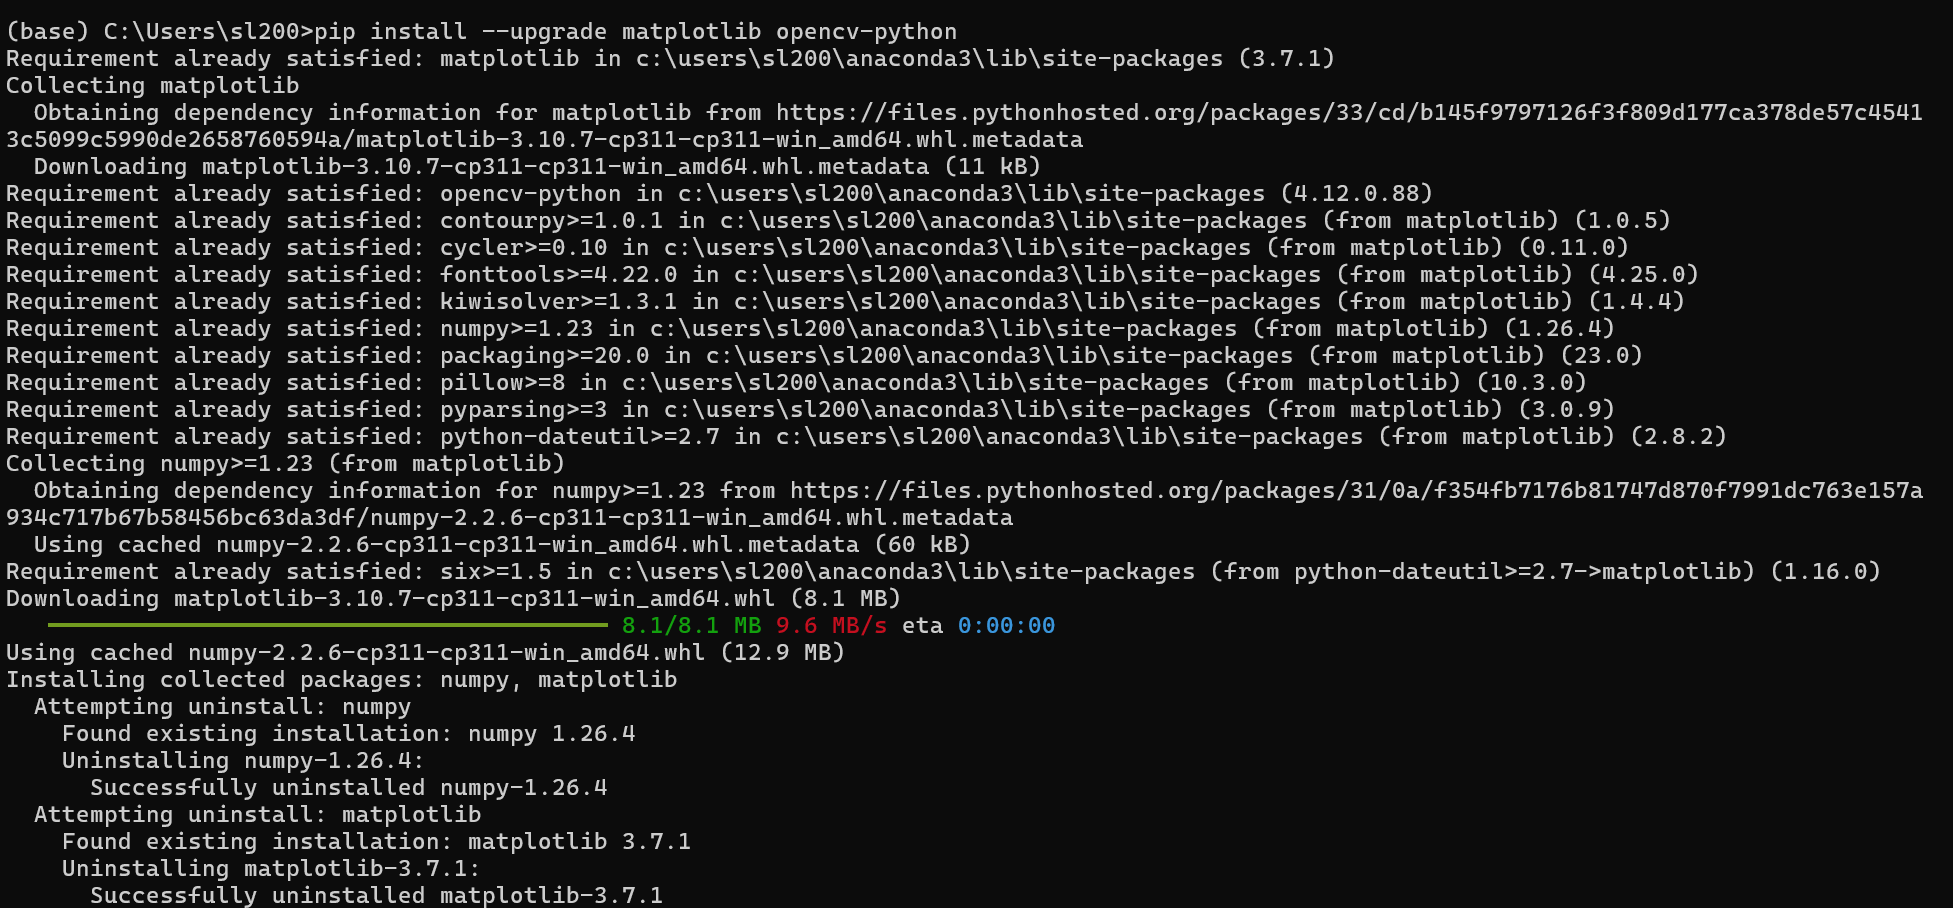

## Kode (HSI mod til Soren)

In [31]:
import numpy as np

def CropToContent(img_matrix, threshold=0.9, padding=20):
    '''
    Crops the image to focus on the dark content (the sample).
    
    Parameters:
    img_matrix: The output from GrayHyperImage (values 0-1)
    threshold:  Values below this are considered "content" (since background is white/1.0).
                Adjust this if the crop cuts off part of the sample.
    padding:    How many pixels of white space to leave around the object.
    '''
    
    # 1. Find the indices of all pixels that are darker than the threshold
    # Since your background is white (approx 1.0), we look for values < threshold
    rows, cols = np.where(img_matrix < threshold)
    
    # If the image is completely white (empty), return original
    if len(rows) == 0:
        print("No content detected below threshold.")
        return img_matrix

    # 2. Find the min and max coordinates (the bounding box)
    min_row, max_row = rows.min(), rows.max()
    min_col, max_col = cols.min(), cols.max()
    
    # 3. Add padding to the bounding box (and ensure we don't go out of bounds)
    min_row = max(0, min_row - padding)
    max_row = min(img_matrix.shape[0], max_row + padding)
    min_col = max(0, min_col - padding)
    max_col = min(img_matrix.shape[1], max_col + padding)
    
    # 4. Slice the array to create the zoomed-in image
    zoomed_image = img_matrix[min_row:max_row, min_col:max_col]
    
    return zoomed_image


def GrayHyperImage(data,bredde):
	'''
	GrayHyperImage tager et HSI datasat (data) med den gamle struktur og
	bredden (bredde) og returnerer en hoj x bred matrix (billede) med vardier mellem 0 og 1.
	billede er egnet til matplotlib.pyplot.imshow 
	'''
	data=np.sum(data,axis=1)
	min_v=data.min()
	maks=data.max()
	data=(data-min_v)/(maks-min_v)
	bred=int(bredde)
	hoj=int(data.shape[0]/bred)
	billede=data.reshape(hoj,bred)
	return billede
 
def read_pam_file(file_path, chan_rmv=None):
    '''
    read_pam_file indlæser en .pam-fil optaget med Mikro-makro-setuppet ved hjaelp af Sunes cam-lib script og returnerer et
    2D-numpy array med den gamle struktur. 
    read_pam_file er en let omskrivning af funktionen modtaget fra Marianna d. 25/7-25.
    '''
    try:
        # Open the .pam file for reading
        with open(file_path, "rb") as file:
            # Function to parse the PAM header until the "ENDHDR" marker
            def parse_pam_header(file):
                header = {}
                while True:
                    line = file.readline().decode("utf-8").strip()
                    #print(line)
                    if not line:
                        break
                    if line == "ENDHDR":
                        break
                    parts = line.split(" ", 1)
                    if len(parts) == 2:
                        key, value = parts
                        header[key] = value
                    elif len(parts) == 1:
                        # Handle lines with no key (just a value)
                        header[line] = None
                return header

            # Parse the PAM header until "ENDHDR"
            header = parse_pam_header(file)

            # Get image properties from the header
            width = int(header["WIDTH"])  # Actual width of image
            channels = int(header["DEPTH"])  # Corresponds to the number of spectral channels
            maxval = int(header["MAXVAL"])
            height = int(header["HEIGHT"])  # Corresponds to the number of scan lines
            interleave = header.get("TUPLTYPE")

            # Read the binary data with the number of channels determined by depth
            data = np.fromfile(file, dtype=np.uint8, count=width * height * channels)

            # image_data = data.reshape(width, height, channels, order='F') # Fortran-style
            if interleave == "BIL":
                image_data = data.reshape(height, width, channels, order='C')  # C-style
            else: #BSQ
                image_data = data.reshape(channels, height, width, order='C')  # C-style
            print("Shape of cube: ", image_data.shape)

            if chan_rmv != None:
                image_data = image_data[chan_rmv:-chan_rmv]
            H, B, W = image_data.shape
            cube_2d = image_data.transpose(0, 2, 1).reshape(H * W, B) 
            return cube_2d, H, B, W

    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# One Image print

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('TkAgg')  # Dette skifter backend til en, der normalt fungerer godt på de fleste systemer
import matplotlib.pyplot as plt
import hsi_mod_til_Soren as hsi

sti = 'data/' #Mappen aendres her
navn = '_HSI_dag_1.3_exp_20k_ref'   #Filnavnet aendres her
b_file = '_HSI_Black_ref'
w_file = '_HSI_White_ref'
fl = sti + navn + ".pam"

data, H, B, W = read_pam_file(fl)

def refrence(file):
    data, H, B, W = read_pam_file(f'{sti}{b_file}.pam')
    billede = GrayHyperImage(data, W)
    # ref = np.mean(billede, axis=0) (Ikke mean)
    ref = billede
    return ref
    
black = refrence(f'{fl}{b_file}.pam')
white = refrence(f'{fl}{w_file}.pam')

billede = GrayHyperImage(data, W)

IC = (billede - black) / (white - black + 1e-12)

zoomed_billede = CropToContent(IC, threshold=0, padding=30)

plt.imshow(zoomed_billede, cmap='gray')
plt.show()

Shape of cube:  (1000, 900, 1296)
Shape of cube:  (500, 900, 1296)
Shape of cube:  (500, 900, 1296)


## Ny kode med alle filer indlæst

In [ ]:
# Prøv i første omgang at indlæse de 7 hyperspektrale billeder. Det er normalt her studerende møde de største udfordringer. Giv mig en melding, når det er lykkedes.

import numpy as np
#import matplotlib
#matplotlib.use('TkAgg')  # Dette skifter backend til en, der normalt fungerer godt på de fleste systemer
import matplotlib.pyplot as plt
import hsi_mod_til_Soren as hsi


sti = "C:/BP/" #Mappen aendres her
filer = ["_HSI_hsi25072402",
        "_HSI_Dark",
        "_HSI_Erbium",
        "_HSI_HDPE_1",
        "_HSI_PP",
        "_HSI_PS",
        "_HSI_white_ref"
        ]
        
data_samlet = []

for navn in filer:
    fl = sti + navn + ".pam"
    print(f"Indlæser fil: {fl}")
    result = hsi.read_pam_file(fl)
    if result is not None:
        data, H, B, W = result
        print(f"-> Data shape: {data.shape}\n")
        data_samlet.append(data)
    else:
        print(f"Fejl ved indlæsning: {fl}")


print(f"\nData indlæst: {len(data_samlet)} filer")
print(f"\nFilerne er indlæst i rækkefølgen:\n{filer}")

Indlæser fil: C:/BP/_HSI_hsi25072402.pam
P7
#Date: 2025-07-24
#Time: 09:49:36
#Gain: 1
#Exposure: 4900
WIDTH 900
HEIGHT 1000
DEPTH 1296
MAXVAL 255
TUPLTYPE BIL
ENDHDR
Shape of cube:  (1000, 900, 1296)
-> Data shape: (1296000, 900)

Indlæser fil: C:/BP/_HSI_Dark.pam
P7
#Date: 2025-04-04
#Time: 09:53:20
#Gain: 1
#Exposure: 3550
WIDTH 900
HEIGHT 1000
DEPTH 1296
MAXVAL 255
TUPLTYPE BIL
ENDHDR
Shape of cube:  (1000, 900, 1296)
-> Data shape: (1296000, 900)

Indlæser fil: C:/BP/_HSI_Erbium.pam
P7
#Date: 2025-04-03
#Time: 13:47:04
#Gain: 1
#Exposure: 3550
WIDTH 900
HEIGHT 1000
DEPTH 1296
MAXVAL 255
TUPLTYPE BIL
ENDHDR
Shape of cube:  (1000, 900, 1296)
-> Data shape: (1296000, 900)

Indlæser fil: C:/BP/_HSI_HDPE_1.pam
P7
#Date: 2025-04-03
#Time: 16:29:07
#Gain: 1
#Exposure: 3550
WIDTH 900
HEIGHT 1000
DEPTH 1296
MAXVAL 255
TUPLTYPE BIL
ENDHDR
Shape of cube:  (1000, 900, 1296)
-> Data shape: (1296000, 900)

Indlæser fil: C:/BP/_HSI_PP.pam
P7
#Date: 2025-04-04
#Time: 07:31:04
#Gain: 1
#Exposure: 

In [ ]:
#plt.imshow(hsi.GrayHyperImage(data_samlet[4], 1296), cmap='gray')
#plt.show()

### Prøv at lave et plot af refleksionsspektrummet (brug dark – og hvidreference ) for forskellige steder på ”_HSI_hsi25072402.pam”.

### Vi bruger data_samlet[0,1,6], og formel 1 fra PDF'en

The reflection is the relation between the incoming and reflected light
$$
R=\frac{I_\text{reflected}}{I_\text{incoming}}=\frac{I_r}{I_i}
$$

With that in mind we use equation (1) from the PDF provided by Bjarke at Newtec.

$$
IC_\text{i,j} = \frac{I_\text{i,j}-B_\text{i,j}}{W_\text{i,j}-B_\text{i,j}}
$$

Where $IC_\text{i,j}$ is the corrected intensity measurement or the reflection, $I_\text{i,j}$ is the initial intensity measurement and $B_\text{i,j}$ and $W_\text{i,j}$ are the black and white refernce pictures respectively.

Lastly, $i$ and $j$ represent the spaital parts of the cube, which is the index for the $x$-components and $y$-components.

In [ ]:
#np.set_printoptions(threshold=np.inf)  # This will show the entire array
print(f"Dataen har følgende form.\n\nx-komponenter: {data.shape[1]} (antal koloner).")
print(f"y-komponenter: {data.shape[0]} (antal rækker).")

#print(f"Datasæt 1:\n{data_samlet[0][:1,:1260]}")

import sympy as sp

# Take a small slice of your data, e.g. first 5 rows and first 5 columns
small_matrix = data[:5, :2]

# Convert to sympy Matrix and pretty print
sp_matrix = sp.Matrix(small_matrix)
sp.pprint(sp_matrix)

Dataen har følgende form.

x-komponenter: 900 (antal koloner).
y-komponenter: 1296000 (antal rækker).
⎡10  10⎤
⎢      ⎥
⎢12  12⎥
⎢      ⎥
⎢11  13⎥
⎢      ⎥
⎢12  9 ⎥
⎢      ⎥
⎣15  10⎦


#### Fejl

In [ ]:
#IC = (data_samlet[0]-data_samlet[1])/(data_samlet[6]-data_samlet[1])

IC = lambda I, B, W: (I-B)/(W-B)

# Inserting the dataset of interest. 
picture = data_samlet[0]

# Defining the references.
black_ref = data_samlet[1]
white_ref = data_samlet[-1]

# Primitive wavelength calibration where we go from near UV to near IR.
wavelength = np.linspace(430, 1700, 900)

# Defining the erbiumoxidspectrum for a more precise wavelength calibration.
erbium = data_samlet[2]

# "Points of interest" chosen 
POFI = [(200,300),(500,600),(800,400)] # (y,x)
#λ
# Calculating the reflection R for each of the PofI
plt.figure(figsize=(12,5))
for (y,x) in POFI:
    R = reflection(picture[y,x,:], black_ref[y,x,:], white_ref[y,x,:])
    plt.plot(wavelength, R, label=f"({y},{x})")

# Defining features of the plot
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflection")
plt.title("Reflection spectrum - 3 PofI")
plt.legend()
plt.grid(True)
plt.show()

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

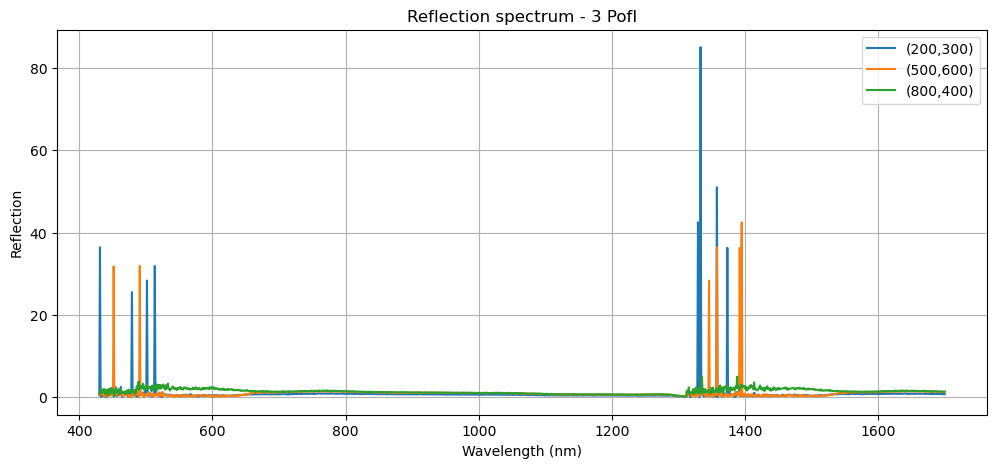

In [ ]:
#IC = (data_samlet[0]-data_samlet[1])/(data_samlet[6]-data_samlet[1])

reflection = lambda I, B, W: (I-B)/(W-B)

# dimensioner
H, W, B = 1000, 900, 1296

# omform til (H, W, B)
picture = data_samlet[0].reshape(H, W, B)
black_ref = data_samlet[1].reshape(H, W, B)
erbium = data_samlet[2].reshape(H, W, B)
white_ref = data_samlet[-1].reshape(H, W, B)

# Primitive wavelength calibration where we go from near UV to near IR.
wavelength = np.linspace(430, 1700, 1296)

# Defining the erbiumoxidspectrum for a more precise wavelength calibration.
#erbium = data_samlet[2]

# "Points of interest" chosen 
POFI = [(200,300),(500,600),(800,400)] # (y,x)

# Calculating the reflection R for each of the PofI
plt.figure(figsize=(12,5))
for (y,x) in POFI:
    R = reflection(picture[y,x,:], black_ref[y,x,:], white_ref[y,x,:])
    plt.plot(wavelength, R, label=f"({y},{x})")


# Defining features of the plot
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflection")
plt.title("Reflection spectrum - 3 PofI")
plt.legend()
plt.grid(True)
plt.show()

#### Plotting reflection

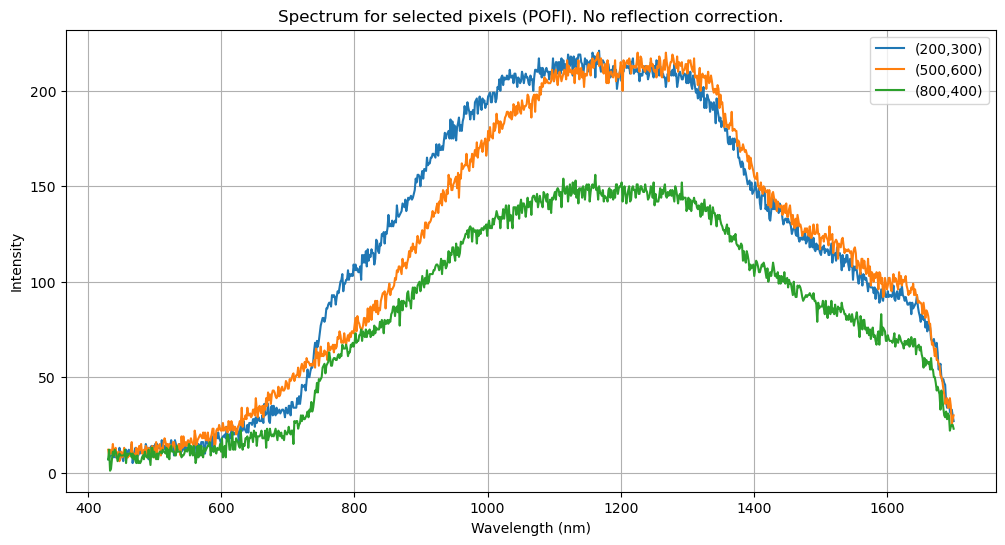

In [ ]:
# Antag at 'data' allerede er indlæst og GrayHyperImage er defineret

%matplotlib inline
# Tilføjet for at sikre visning i Jupyter Notebooks

# Vis gråtonebillede
#billede = GrayHyperImage(data, 1296)
#plt.imshow(billede, cmap='gray')
#plt.title("Summed grayscale image")
#plt.show()

# Definer punkter af interesse (POFI) som (y, x)
POFI = [(200, 300), (500, 600), (800, 400)]

# Plot spektrum for hvert punkt i POFI
plt.figure(figsize=(12, 6))
wavelength = np.linspace(430, 1700, data.shape[1])  # Antal kanaler = data.shape[1]
for (y, x) in POFI:
    pixel_index = y * 1296 + x  # 1296 er billedets bredde
    spectrum = data[pixel_index, :]
    plt.plot(wavelength, spectrum, label=f"({y},{x})")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Spectrum for selected pixels (POFI). No reflection correction.")
plt.legend()
plt.grid(True)
plt.show()

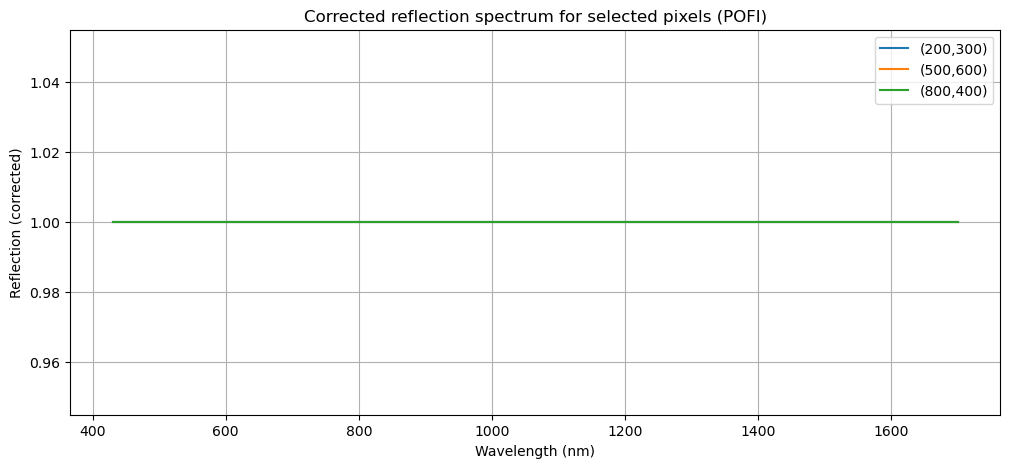

In [ ]:
# Antag at data, black_ref, white_ref allerede er indlæst (alle i samme format)
POFI = [(200, 300), (500, 600), (800, 400)]
plt.figure(figsize=(12, 5))
wavelength = np.linspace(430, 1700, data.shape[1])

epsilon = 1e-8  # Small value to avoid division by zero

for (y, x) in POFI:
    idx = y * 1296 + x
    I = data[idx, :].astype(float)
    B = black_ref[idx, :].astype(float)
    W = white_ref[idx, :].astype(float)
    denominator = W - B
    denominator = denominator.astype(float)  # Ensure float type
    denominator[np.abs(denominator) < epsilon] = np.nan  # Avoid division by zero
    IC = (I - B) / denominator
    plt.plot(wavelength, IC, label=f"({y},{x})")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflection (corrected)")
plt.title("Corrected reflection spectrum for selected pixels (POFI)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
idx = 200 * 1296 + 300
print("I:", data[idx, :10])
print("B:", black_ref[idx, :10])
print("W:", white_ref[idx, :10])
print("W - B:", white_ref[idx, :10] - black_ref[idx, :10])
print("I - B:", data[idx, :10] - black_ref[idx, :10])

I: [13 10  8 12  8 10 13  9 12 10]
B: [4 2 1 6 1 1 8 1 4 4]
W: [13 10  8 12  8 10 13  9 12 10]
W - B: [9 8 7 6 7 9 5 8 8 6]
I - B: [9 8 7 6 7 9 5 8 8 6]


Error caused due to $I$ and $W$ being identical

In [ ]:
data = data_samlet[0]
black_ref = data_samlet[1]
white_ref = data_samlet[-1]

print("Sample file:", filer[0])
print("Black ref file:", filer[1])
print("White ref file:", filer[-1])
print(f"\nSample shape:", data.shape)
print("Black ref shape:", black_ref.shape)
print("White ref shape:", white_ref.shape)

Sample file: _HSI_hsi25072402
Black ref file: _HSI_Dark
White ref file: _HSI_white_ref

Sample shape: (1296000, 900)
Black ref shape: (1296000, 900)
White ref shape: (1296000, 900)


### Prøv at lave et RGB-billede af ”_HSI_hsi25072402.pam”. Det kan gøres på forskellige måder. Giv mig en melding, når det lykkedes. 

Red wavelength: 575.51 nm (index 103)
Green wavelength: 550.08 nm (index 85)
Blue wavelength: 500.63 nm (index 50)


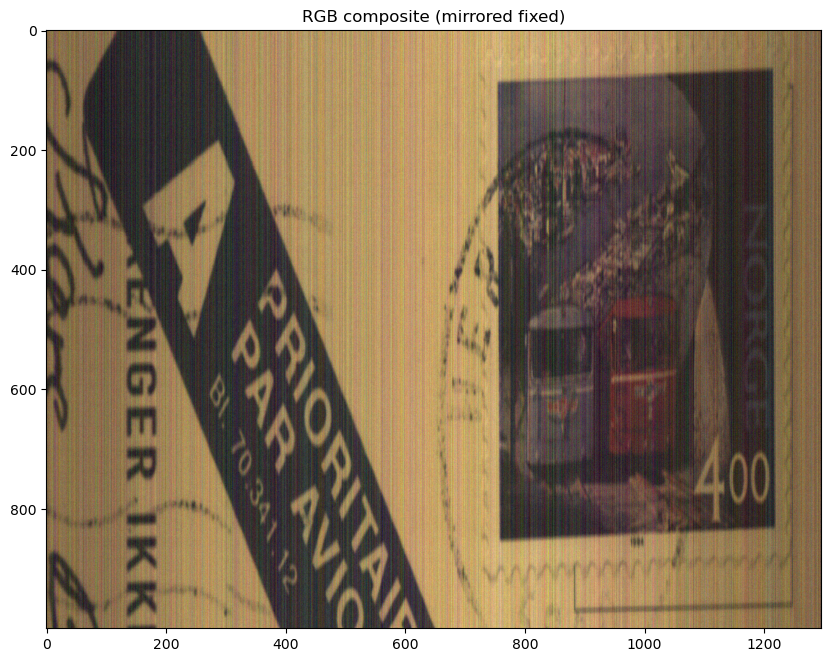

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Parameters
height, width = 1000, 1296  # Adjust if your image shape is different
bands = data_samlet[0].shape[1]

# Reshape to (height, width, bands)
cube = data_samlet[0].reshape(height, width, bands)

# Choose band indices for R, G, B (example: 650nm, 550nm, 450nm)
wavelengths = np.linspace(430, 1700, bands)

# Optimal_1 (Manual)
red_idx = np.argmin(np.abs(wavelengths - 575)) # Example for red channel (started at 600)
green_idx = np.argmin(np.abs(wavelengths - 550)) # Example for green channel (started at 550)
blue_idx = np.argmin(np.abs(wavelengths - 500)) # Example for blue channel (started at 450)

# Optimal_2 (Manual)
#red_idx = np.argmin(np.abs(wavelengths - 570))
#green_idx = np.argmin(np.abs(wavelengths - 545))
#blue_idx = np.argmin(np.abs(wavelengths - 500))

# Optimal_3 (Google)
#red_idx = np.argmin(np.abs(wavelengths - 575))
#green_idx = np.argmin(np.abs(wavelengths - 535))
#blue_idx = np.argmin(np.abs(wavelengths - 445))

# Print the actual wavelengths used
print(f"Red wavelength: {wavelengths[red_idx]:.2f} nm (index {red_idx})")
print(f"Green wavelength: {wavelengths[green_idx]:.2f} nm (index {green_idx})")
print(f"Blue wavelength: {wavelengths[blue_idx]:.2f} nm (index {blue_idx})")

# Stack into RGB image
rgb = np.stack([
    cube[:, :, red_idx],
    cube[:, :, green_idx],
    cube[:, :, blue_idx]
], axis=-1)

# Normalize for display
rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())

rgb_norm_flipped = np.fliplr(rgb_norm)
plt.figure(figsize=(10, 8))
plt.imshow(rgb_norm_flipped)
plt.title("RGB composite (mirrored fixed)")
plt.axis('on')
plt.show()


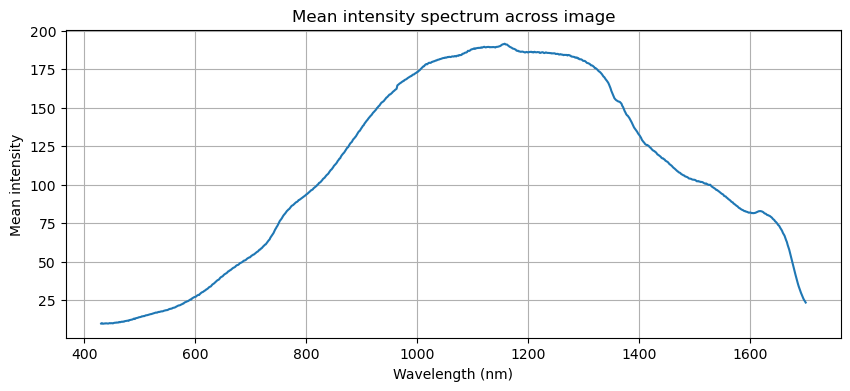

Suggested RGB wavelengths (visible): [489.33259177 538.77641824 605.17241379]


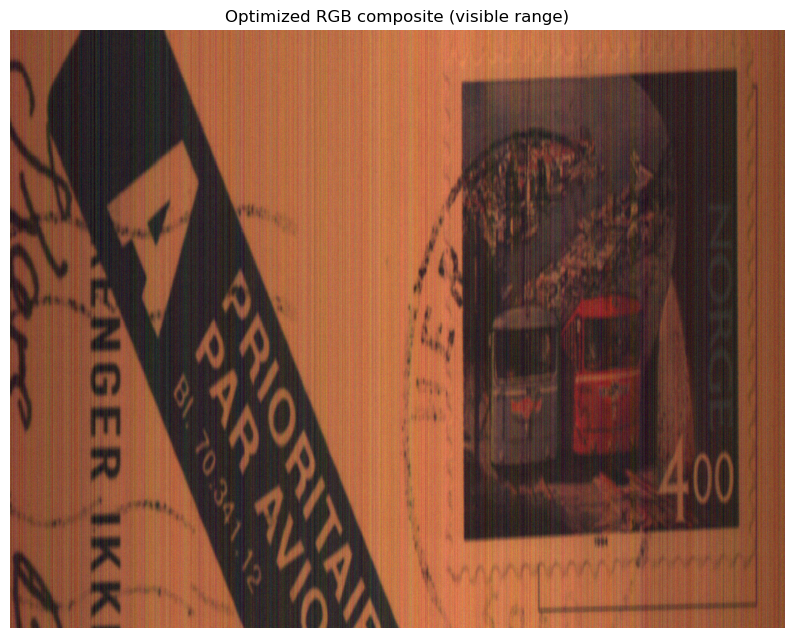

In [ ]:
# Optimized version with corrected band indices

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Reshape data to (height, width, bands)
cube = data_samlet[0].reshape(1000, 1296, -1)
bands = cube.shape[2]
wavelengths = np.linspace(430, 1700, bands)

# 1. Plot mean intensity for each wavelength
mean_spectrum = cube.mean(axis=(0, 1))
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, mean_spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean intensity")
plt.title("Mean intensity spectrum across image")
plt.grid(True)
plt.show()

# 2. Function to suggest RGB bands based on intensity peaks
from scipy.signal import find_peaks

def suggest_rgb_bands_visible(mean_spectrum, wavelengths, vis_min=430, vis_max=700):
    # Only consider visible range
    vis_mask = (wavelengths >= vis_min) & (wavelengths <= vis_max)
    vis_spectrum = mean_spectrum[vis_mask]
    vis_wavelengths = wavelengths[vis_mask]
    peaks, _ = find_peaks(vis_spectrum, distance=30)
    sorted_peaks = peaks[np.argsort(vis_spectrum[peaks])[::-1]]
    if len(sorted_peaks) >= 3:
        rgb_indices_vis = np.sort(sorted_peaks[:3])
        # Map back to original indices
        rgb_indices = np.where(vis_mask)[0][rgb_indices_vis]
        print("Suggested RGB wavelengths (visible):", wavelengths[rgb_indices])
        return rgb_indices
    else:
        print("Not enough peaks found in visible, using default bands.")
        return [np.argmin(np.abs(wavelengths - 650)),
                np.argmin(np.abs(wavelengths - 550)),
                np.argmin(np.abs(wavelengths - 450))]

# Usage:
rgb_indices = suggest_rgb_bands_visible(mean_spectrum, wavelengths)

# Create and show optimized RGB image
rgb = np.stack([
    cube[:, :, rgb_indices[2]],  # Red
    cube[:, :, rgb_indices[1]],  # Green
    cube[:, :, rgb_indices[0]],  # Blue
], axis=-1)

rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min())
plt.figure(figsize=(10, 8))
plt.imshow(np.fliplr(rgb_norm))
plt.title("Optimized RGB composite (visible range)")
plt.axis('off')
plt.show()

### Læs om CIR (color-infrared) og prøv evt. også at lave et CIR-billede.

Red wavelength: 800.12 nm (index 262)
Green wavelength: 650.38 nm (index 156)
Blue wavelength: 550.08 nm (index 85)


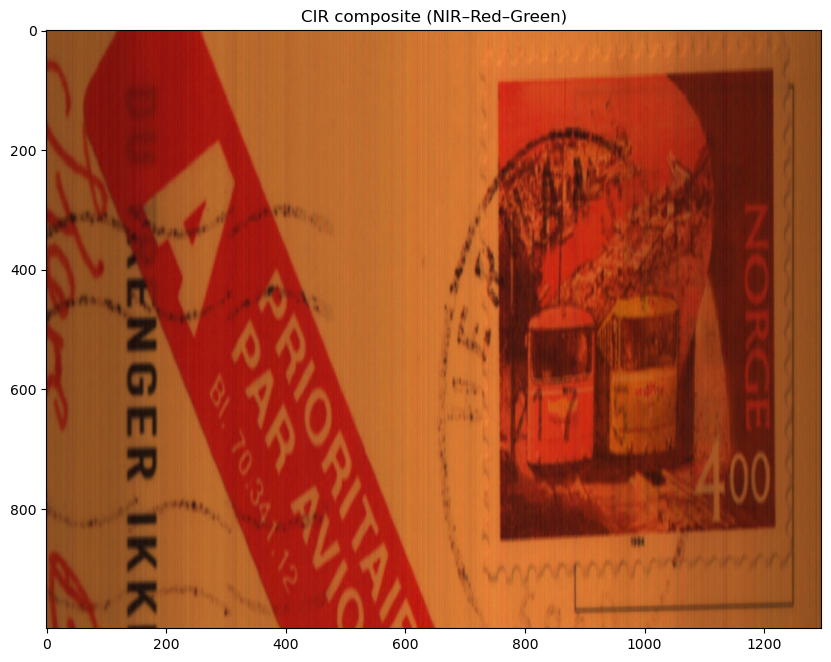

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
height, width = 1000, 1296  # Adjust if your image shape is different
bands = data_samlet[0].shape[1]

# Reshape to (height, width, bands)
cube = data_samlet[0].reshape(height, width, bands)

# Choose band indices for R, G, B (example: 650nm, 550nm, 450nm)
wavelengths = np.linspace(430, 1700, bands)

# --- CIR valg ---
nir_idx   = np.argmin(np.abs(wavelengths - 800))  # Nær-infrarød → Red kanal
red_idx   = np.argmin(np.abs(wavelengths - 650))  # Rødt → Green kanal
green_idx = np.argmin(np.abs(wavelengths - 550))  # Grønt → Blue kanal

# Print the actual wavelengths used
print(f"Red wavelength: {wavelengths[nir_idx]:.2f} nm (index {nir_idx})")
print(f"Green wavelength: {wavelengths[red_idx]:.2f} nm (index {red_idx})")
print(f"Blue wavelength: {wavelengths[green_idx]:.2f} nm (index {green_idx})")

# Stack into RGB image
CIR = np.stack([
    cube[:, :, nir_idx],
    cube[:, :, red_idx],
    cube[:, :, green_idx]
], axis=-1)

# Normalize for display
CIR_norm = (CIR - CIR.min()) / (CIR.max() - CIR.min())

CIR_norm_flipped = np.fliplr(CIR_norm)
plt.figure(figsize=(10, 8))
plt.imshow(CIR_norm_flipped)
plt.title("CIR composite (NIR–Red–Green)")
plt.axis('on')
plt.show()
